# Analiza Szeregów Czasowych - Lab. 9 (26 XI 2025)
# TEMAT: Studium symulacyjne (cd.) i modelarskie dla szeregów GARCH

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import shapiro

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox

from arch import arch_model

# Ustawienia wykresów (niekonieczne, ale wygodne)

In [12]:
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

# 1. Symulacja trajektorii modelu GARCH(1,1) - wersja "revisited"


In [13]:
np.random.seed(123)  # dla odtwarzalności

In [14]:
# parametry modelu
omega = 1e-6
alpha = 0.2
beta = 0.7

In [15]:
n = 300          # długość serii po odcięciu rozgrzewki
burn_in = 200    # odpowiednik n.start w R
T = n + burn_in  # całkowita liczba kroków

In [16]:
# wektory na symulację
eps = np.random.normal(size=T)        # innowacje ~ N(0,1)
sigma2 = np.zeros(T)                  # wariancja warunkowa
r = np.zeros(T)                       # zwroty r_t

In [17]:
# startowa wariancja: wariancja bezwarunkowa GARCH(1,1)
sigma2[0] = omega / (1 - alpha - beta)
r[0] = np.sqrt(sigma2[0]) * eps[0]

In [18]:
for t in range(1, T):
    sigma2[t] = omega + alpha * r[t-1]**2 + beta * sigma2[t-1]
    r[t] = np.sqrt(sigma2[t]) * eps[t]

In [19]:
# odcięcie rozgrzewki (extended = TRUE, n.start = 200 w R)
rt = r[burn_in:]
epst = eps[burn_in:]
sigmat = np.sqrt(sigma2[burn_in:])

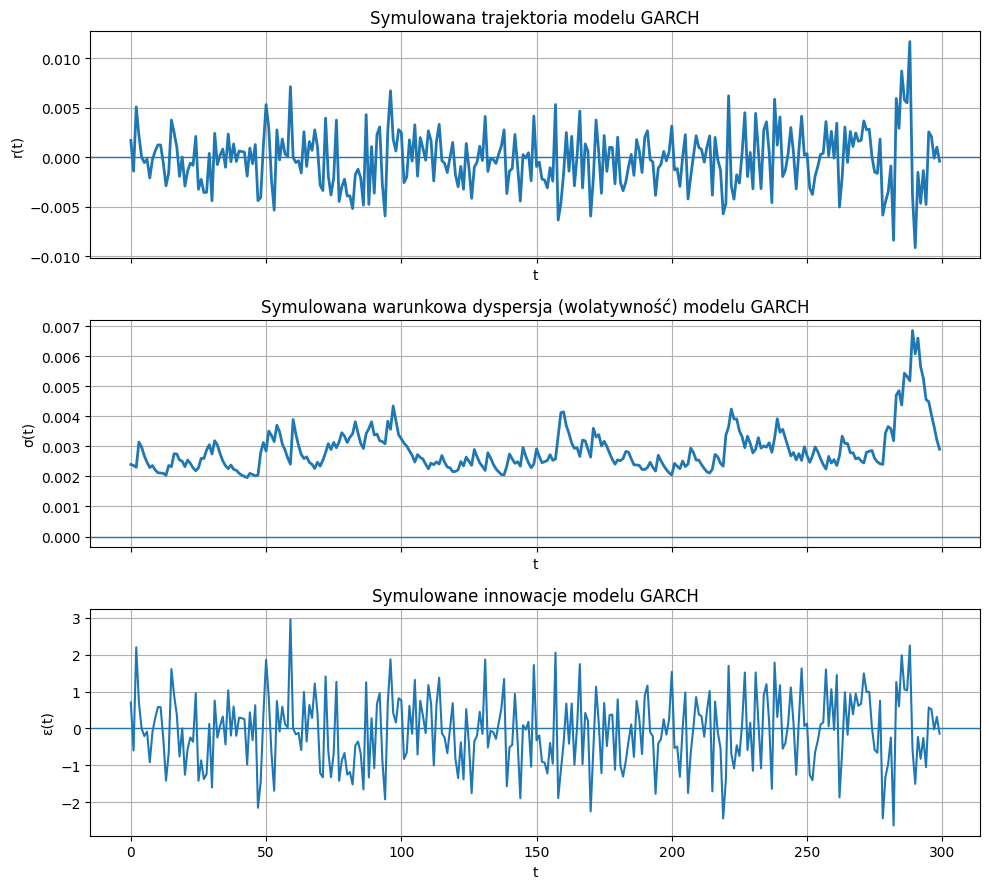

In [23]:
# wizualizacja trajektorii i składowych
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

axes[0].plot(rt, linewidth=2)
axes[0].axhline(0, linewidth=1)
axes[0].set_title("Symulowana trajektoria modelu GARCH")
axes[0].set_xlabel("t")
axes[0].set_ylabel("r(t)")

axes[1].plot(sigmat, linewidth=2)
axes[1].axhline(0, linewidth=1)
axes[1].set_title("Symulowana warunkowa dyspersja (wolatywność) modelu GARCH")
axes[1].set_xlabel("t")
axes[1].set_ylabel("σ(t)")

axes[2].plot(epst, linewidth=1.5)
axes[2].axhline(0, linewidth=1)
axes[2].set_title("Symulowane innowacje modelu GARCH")
axes[2].set_xlabel("t")
axes[2].set_ylabel("ε(t)")

plt.tight_layout()
plt.show()

In [21]:
axes[0].plot(rt, linewidth=2)
axes[0].axhline(0, linewidth=1)
axes[0].set_title("Symulowana trajektoria modelu GARCH")
axes[0].set_xlabel("t")
axes[0].set_ylabel("r(t)")

Text(4.444444444444452, 0.5, 'r(t)')

In [24]:
# test normalności Shapiro-Wilka i wariancja
shapiro_stat, shapiro_p = shapiro(rt)
print("Shapiro-Wilk dla rt: stat =", shapiro_stat, ", p-value =", shapiro_p)

print("Var(rt) =", np.var(rt, ddof=1))

Shapiro-Wilk dla rt: stat = 0.9924687297466297 , p-value = 0.13352412238787564
Var(rt) = 8.218466273066219e-06


# 2. Praca z danymi realnymi: log-zwroty Bitcoin
     Dane: https://fred.stlouisfed.org/series/CBBTCUSD
     Plik lokalny: CBBTCUSDd.csv


## a) analizy wstępne dla dziennych (tygodniowych wg opisu) cen Bitcoin


In [25]:
# Wczytanie danych (zakładam, że plik ma kolumny: Data, BTC)
daneD = pd.read_csv("CBBTCUSDd.csv", decimal=".")

In [26]:
# nazwy kolumn zgodnie z R
daneD.columns = ["Data", "BTC"]

In [27]:
# jeżeli Data jest tekstem, parsujemy na datę
try:
    daneD["Data"] = pd.to_datetime(daneD["Data"])
except Exception:
    pass

In [28]:
Xtd = daneD["BTC"].astype(float)

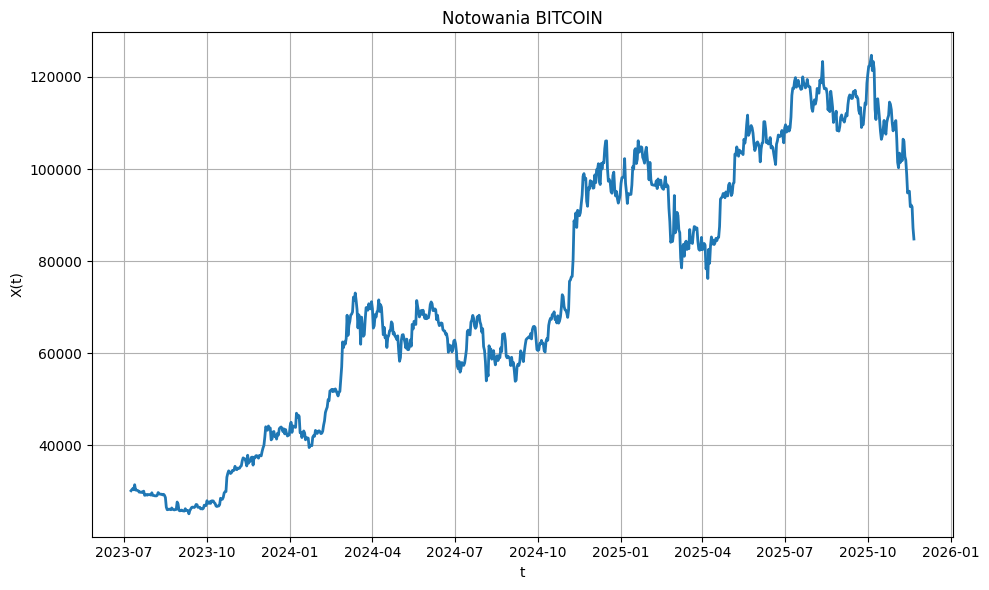

In [51]:
plt.plot(daneD["Data"], Xtd, linewidth=2)
plt.xlabel("t")
plt.ylabel("X(t)")
plt.title("Notowania BITCOIN")
plt.grid(True)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

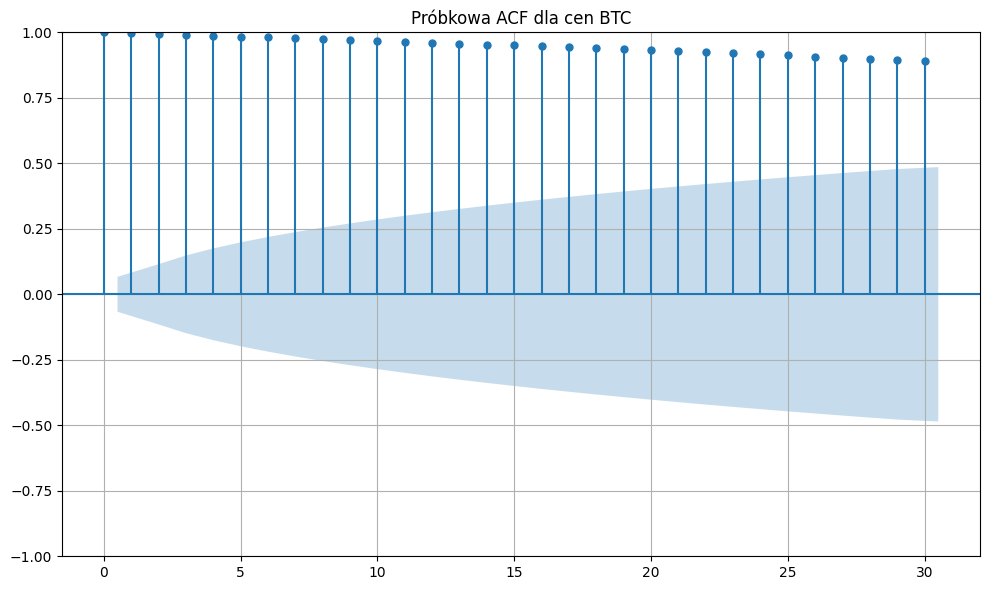

In [30]:
# ACF dla poziomów cen
plt.figure()
plot_acf(Xtd.dropna(), lags=30)
plt.title("Próbkowa ACF dla cen BTC")
plt.tight_layout()
plt.show()

In [32]:
# Test DF (ADF) i KPSS
adf_res = adfuller(Xtd.dropna())
kpss_res = kpss(Xtd.dropna(), regression="c", nlags="auto")

print("\nTest ADF (DF):")
print("  stat =", adf_res[0], ", p-value =", adf_res[1])

print("\nTest KPSS:")
print("  stat =", kpss_res[0], ", p-value =", kpss_res[1])



Test ADF (DF):
  stat = -1.470925434221737 , p-value = 0.5478419702280646

Test KPSS:
  stat = 4.256108820257691 , p-value = 0.01


C:\Users\Paweł\AppData\Local\Temp\ipykernel_27448\250142445.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(Xtd.dropna(), regression="c", nlags="auto")


In [33]:
# dla pełniejszego odpowiednika c(TestDF$statistic,TestDF$p.value)
TestDF = (adf_res[0], adf_res[1])
TestKP = (kpss_res[0], kpss_res[1])
print("\nc(TestDF$statistic, TestDF$p.value) =", TestDF)
print("c(TestKP$statistic, TestKP$p.value) =", TestKP)


c(TestDF$statistic, TestDF$p.value) = (np.float64(-1.470925434221737), np.float64(0.5478419702280646))
c(TestKP$statistic, TestKP$p.value) = (np.float64(4.256108820257691), np.float64(0.01))


## b) Analiza wstępna dziennych log-zwrotów BTC



In [34]:
# log-zwroty
Rtd = np.log(Xtd).diff().dropna()

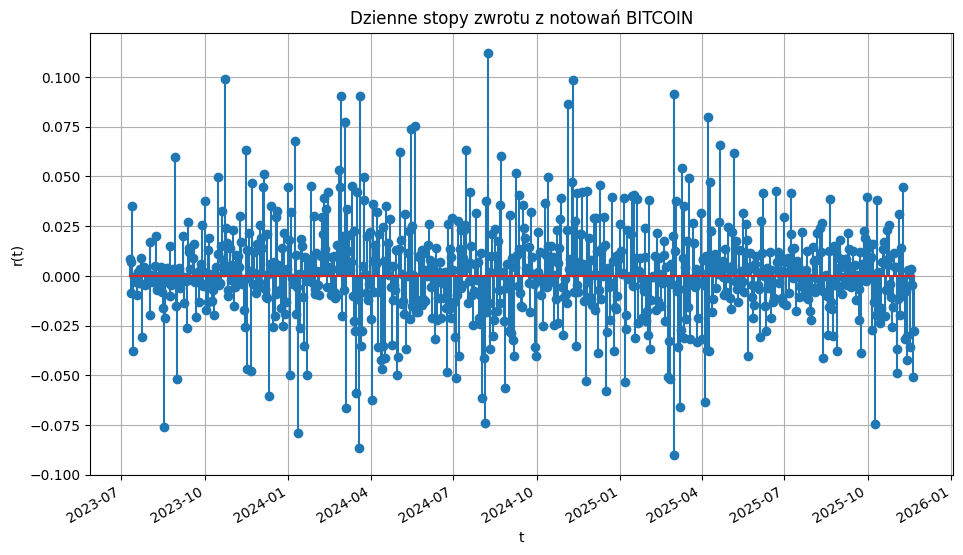

In [37]:
# dopasujmy daty i zwroty do tej samej osi (usuwa problemy z indeksami/typami)
dates = pd.to_datetime(daneD["Data"].iloc[1:]).reset_index(drop=True)
y = Rtd.reset_index(drop=True)

plt.figure()
# odpowiednik type = "h": słupki
# usuń nieobsługiwany argument use_line_collection
plt.stem(dates.values, y.values)
plt.xlabel("t")
plt.ylabel("r(t)")
plt.title("Dzienne stopy zwrotu z notowań BITCOIN")
plt.grid(True)
plt.tight_layout()
plt.gcf().autofmt_xdate()
plt.show()


In [38]:
# test normalności Shapiro-Wilka
shapiro_stat_R, shapiro_p_R = shapiro(Rtd)
print("\nShapiro-Wilk dla Rtd: stat =", shapiro_stat_R, ", p-value =", shapiro_p_R)


Shapiro-Wilk dla Rtd: stat = 0.9617177011398156 , p-value = 2.824391346548496e-14


<Figure size 1000x600 with 0 Axes>

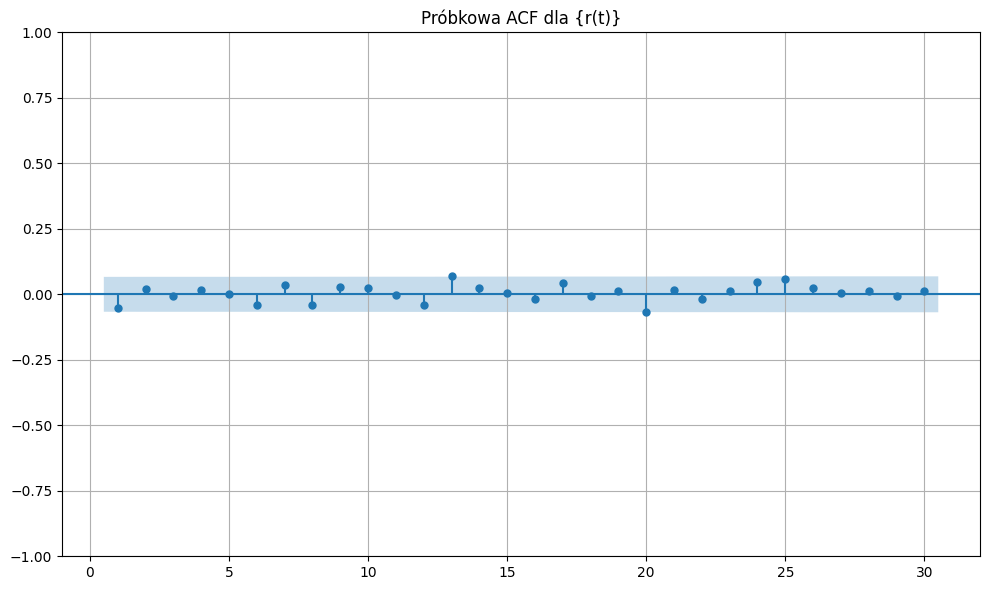

In [52]:
# ACF dla zwrotów
plt.figure()
plot_acf(Rtd, lags=30, zero=False)
plt.title("Próbkowa ACF dla {r(t)}")
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

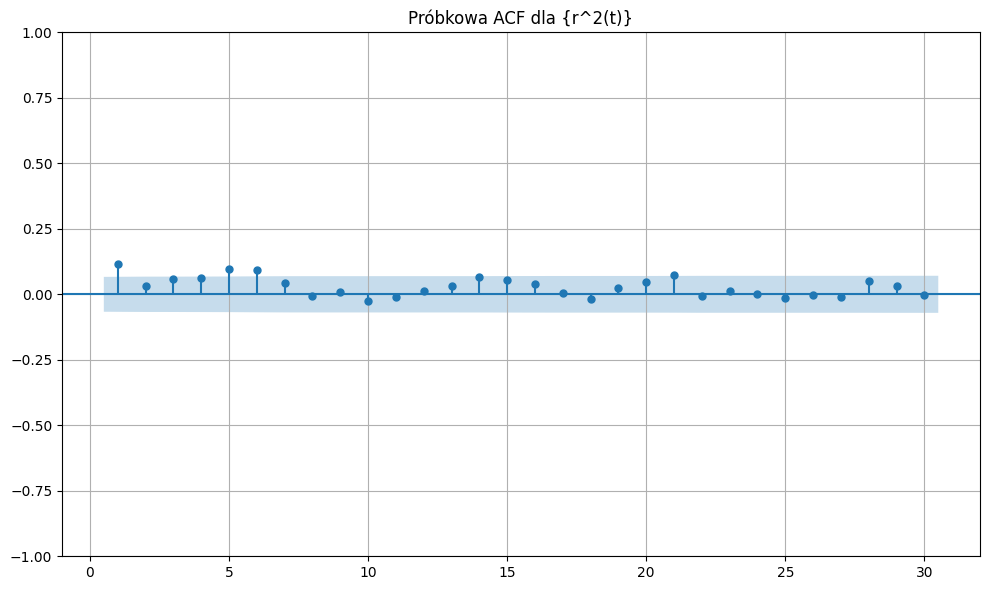

In [53]:
# ACF dla kwadratów zwrotów
plt.figure()
plot_acf(Rtd ** 2, lags=30, zero = False)
plt.title("Próbkowa ACF dla {r^2(t)}")
plt.tight_layout()
plt.show()


In [42]:
# testy Ljunga-Boxa dla r(t) i r^2(t), lag = 10
lb_ret = acorr_ljungbox(Rtd, lags=[10], return_df=True)
lb_ret2 = acorr_ljungbox(Rtd ** 2, lags=[10], return_df=True)

print("\nLjung-Box dla Rtd, lag=10:")
print(lb_ret)

print("\nLjung-Box dla Rtd^2, lag=10:")
print(lb_ret2)



Ljung-Box dla Rtd, lag=10:
    lb_stat  lb_pvalue
10  8.15887   0.613322

Ljung-Box dla Rtd^2, lag=10:
     lb_stat  lb_pvalue
10  36.50968   0.000069


## c) dopasowanie modelu GARCH(1,1) - QMLE


In [43]:
# w R często używa się 100 * r(t); zrobimy analogicznie
Rtd_pct = 100 * Rtd

In [44]:
# dopasowanie GARCH(1,1)
am = arch_model(Rtd_pct, vol="GARCH", p=1, q=1, dist="normal", mean="Constant")
modelg11 = am.fit(update_freq=10, disp="off")

print("\nEstymatory QMLE (parametry modelu GARCH(1,1)):")
print(modelg11.params)

print("\nPodsumowanie modelu GARCH(1,1):")
print(modelg11.summary())


Estymatory QMLE (parametry modelu GARCH(1,1)):
mu          0.122330
omega       0.466481
alpha[1]    0.075135
beta[1]     0.848633
Name: params, dtype: float64

Podsumowanie modelu GARCH(1,1):
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                    BTC   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1980.30
Distribution:                  Normal   AIC:                           3968.60
Method:            Maximum Likelihood   BIC:                           3987.66
                                        No. Observations:                  866
Date:                Wed, Nov 26 2025   Df Residuals:                      865
Time:                        11:23:23   Df Model:                            1
                                 Mean Model                                
                 co

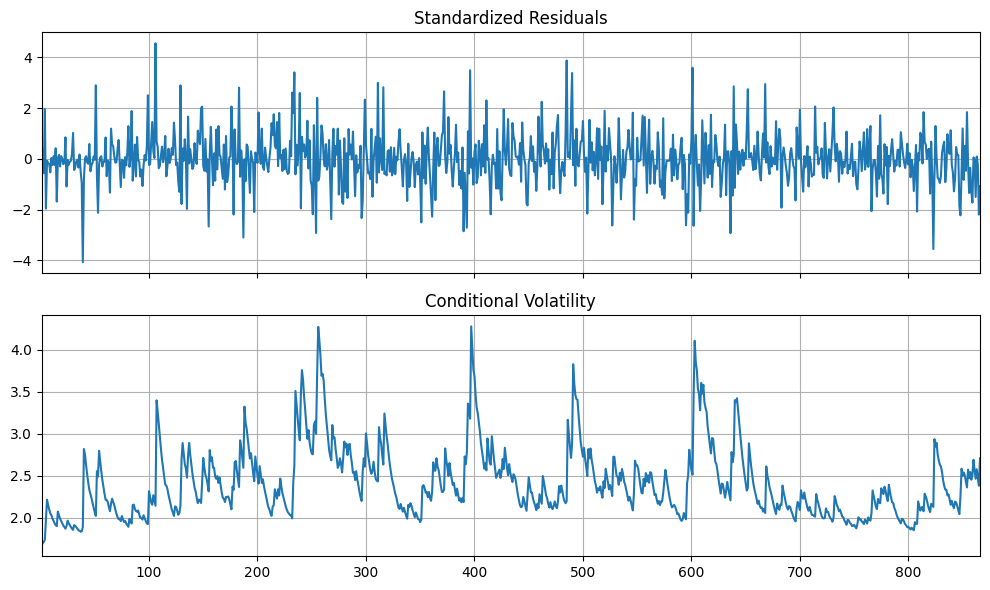

In [45]:
# diagnostyka graficzna (odpowiednik plot(modelg11) w R)
fig = modelg11.plot()
plt.tight_layout()
plt.show()


# Diagnostyka 3: analiza reszt z modelu GARCH


In [46]:
epst_ = modelg11.resid   # reszty (niekoniecznie standaryzowane)


In [47]:
# test Shapiro-Wilka dla reszt
shapiro_stat_eps, shapiro_p_eps = shapiro(epst_)
print("\nShapiro-Wilk dla reszt modelu GARCH: stat =", shapiro_stat_eps,
      ", p-value =", shapiro_p_eps)



Shapiro-Wilk dla reszt modelu GARCH: stat = 0.9617177011398156 , p-value = 2.824391346548496e-14


In [48]:
# "gedFit(epst_)" – w Pythonie najprościej: dopasować GARCH z rozkładem GED
am_ged = arch_model(Rtd_pct, vol="GARCH", p=1, q=1, dist="ged", mean="Constant")
modelg11_ged = am_ged.fit(update_freq=10, disp="off")

In [49]:
print("\nModel GARCH(1,1) z rozkładem GED (odpowiednik gedFit):")
print(modelg11_ged.summary())


Model GARCH(1,1) z rozkładem GED (odpowiednik gedFit):
                           Constant Mean - GARCH Model Results                            
Dep. Variable:                                BTC   R-squared:                       0.000
Mean Model:                         Constant Mean   Adj. R-squared:                  0.000
Vol Model:                                  GARCH   Log-Likelihood:               -1920.87
Distribution:      Generalized Error Distribution   AIC:                           3851.73
Method:                        Maximum Likelihood   BIC:                           3875.55
                                                    No. Observations:                  866
Date:                            Wed, Nov 26 2025   Df Residuals:                      865
Time:                                    11:24:40   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t     